In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
import seaborn as sns

In [17]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 2.5 MB/s eta 0:00:04
   ---- ----------------------------------- 1.0/9.5 MB 2.1 MB/s eta 0:00:05
   ------- -------------------------------- 1.8/9.5 MB 2.4 MB/s eta 0:00:04
   ---------- ----------------------------- 2.6/9.5 MB 2.8 MB/s eta 0:00:03
   -------------- ------------------------- 3.4/9.5 MB 3.0 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.5 MB 3.2 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.5 MB 3.4 MB/s eta 0:00:02
   -------------------------- ------------- 6.3/9.5 MB 3.5 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.5 MB 3.6 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.5 MB 3.7 MB/s eta 0:00:01
   ------------------------------------- -- 8.9/9.5 MB 3.8 MB/s eta 0:00:01
   -----------------------

In [14]:
df = pd.read_csv(r"C:\Users\selva\Desktop\Tumo Labs\Station project 1 - ML\Sales_prediction\data\advertising.csv")
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [15]:
# features and target
X = df[["TV", "Radio", "Newspaper"]]  
y = df["Sales"]                      

In [6]:
# train 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
# evaluate 
score = model.score(X_test, y_test)
print("Model R² Score:", score)

Model R² Score: 0.9059011844150826


In [8]:
# make prediction
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(results.head())

   Actual  Predicted
0    16.9  17.034772
1    22.4  20.409740
2    21.4  23.723989
3     7.3   9.272785
4    24.7  21.682719


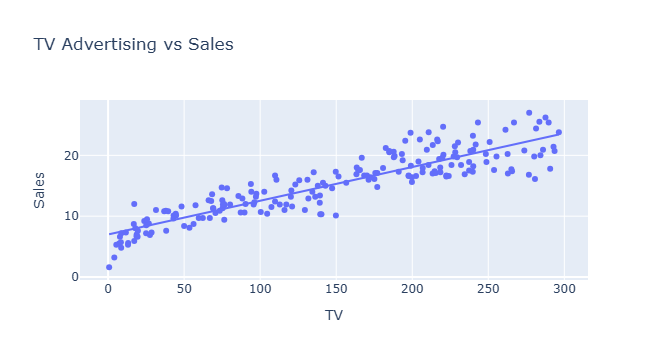

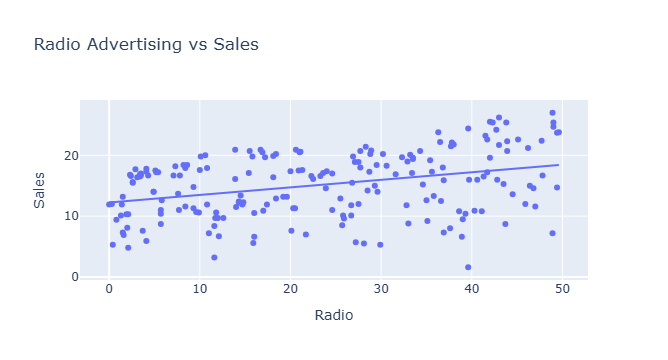

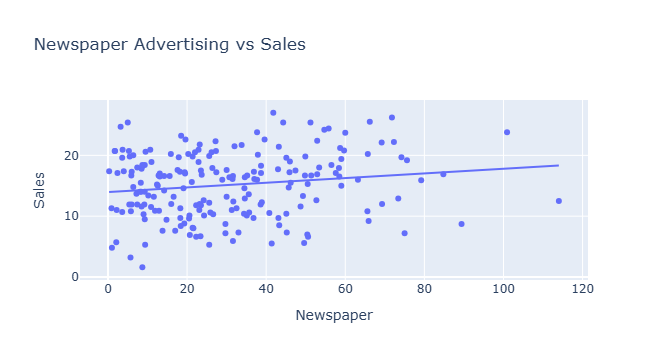

In [18]:
# visualization: relationships 
fig1 = px.scatter(df, x="TV", y="Sales", title="TV Advertising vs Sales", trendline="ols")
fig1.show()

fig2 = px.scatter(df, x="Radio", y="Sales", title="Radio Advertising vs Sales", trendline="ols")
fig2.show()

fig3 = px.scatter(df, x="Newspaper", y="Sales", title="Newspaper Advertising vs Sales", trendline="ols")
fig3.show()

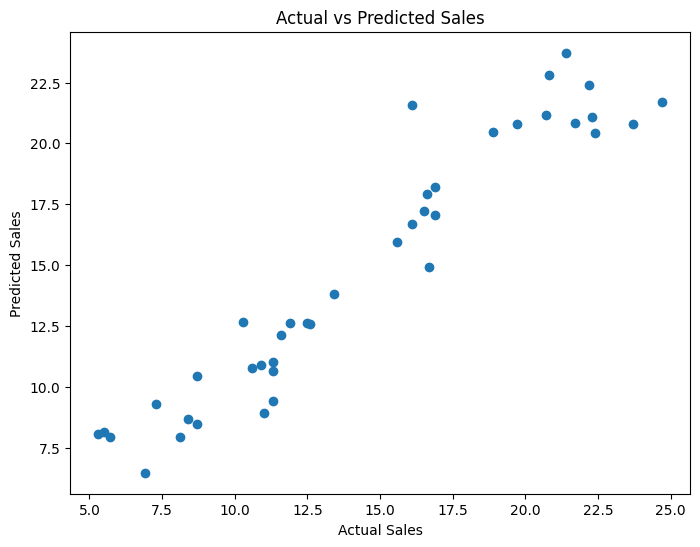

In [11]:
# visualization: actual vs predicted

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()